# 🎬 Movie Recommender System — Advanced Edition

This notebook rebuilds the original content-based movie recommender as a proper end-to-end
data science project:

1. Data loading & sanity checks
2. Exploratory Data Analysis (EDA)
3. Data cleaning & feature engineering
4. Baseline: popularity-based recommender
5. Content-based filtering (CountVectorizer vs TF-IDF, multiple hyperparameters)
6. Model evaluation with a genre-overlap precision@k proxy metric
7. Hybrid recommender (content similarity + quality re-ranking)
8. Persisting the winning model for deployment

**Dataset:** [TMDB 5000 Movie Dataset](https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata)
(`tmdb_5000_movies.csv` + `tmdb_5000_credits.csv`)


## 1. Setup & Imports

In [1]:
# !pip install nltk

In [2]:
import ast
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler

import nltk
from nltk.stem.porter import PorterStemmer

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42


## 2. Data Loading

Update `DATA_DIR` to point at the folder containing `tmdb_5000_movies.csv` and
`tmdb_5000_credits.csv`. Using a variable instead of hardcoded absolute paths makes the
notebook portable across machines.

In [3]:
DATA_DIR = Path("data")  # <-- change this if your CSVs live elsewhere

movies_path = DATA_DIR / "tmdb_5000_movies.csv"
credits_path = DATA_DIR / "tmdb_5000_credits.csv"

assert movies_path.exists(), f"Could not find {movies_path}. Update DATA_DIR."
assert credits_path.exists(), f"Could not find {credits_path}. Update DATA_DIR."

movies_raw = pd.read_csv(movies_path)
credits_raw = pd.read_csv(credits_path)

print("movies:", movies_raw.shape)
print("credits:", credits_raw.shape)


movies: (4803, 20)
credits: (4803, 4)


In [4]:
movies_raw.head(3)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466


In [5]:
credits_raw.head(3)

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


In [6]:
movies_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   str    
 10  production_countries  4803 non-null   str    
 11  release_date          4802 non-null   str    
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   str    
 15  status                4803 non-n

## 3. Exploratory Data Analysis (EDA)

Before touching the data, understand what's actually in it: missingness, distributions,
outliers, and relationships between fields. This shapes every feature engineering decision
that follows.

### 3.1 Missing values & duplicates

In [7]:
missing = movies_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

print("\nDuplicate rows:", movies_raw.duplicated().sum())
print("Duplicate titles:", movies_raw['title'].duplicated().sum())


homepage        3091
tagline          844
overview           3
runtime            2
release_date       1
dtype: int64

Duplicate rows: 0
Duplicate titles: 3


### 3.2 Numeric feature distributions

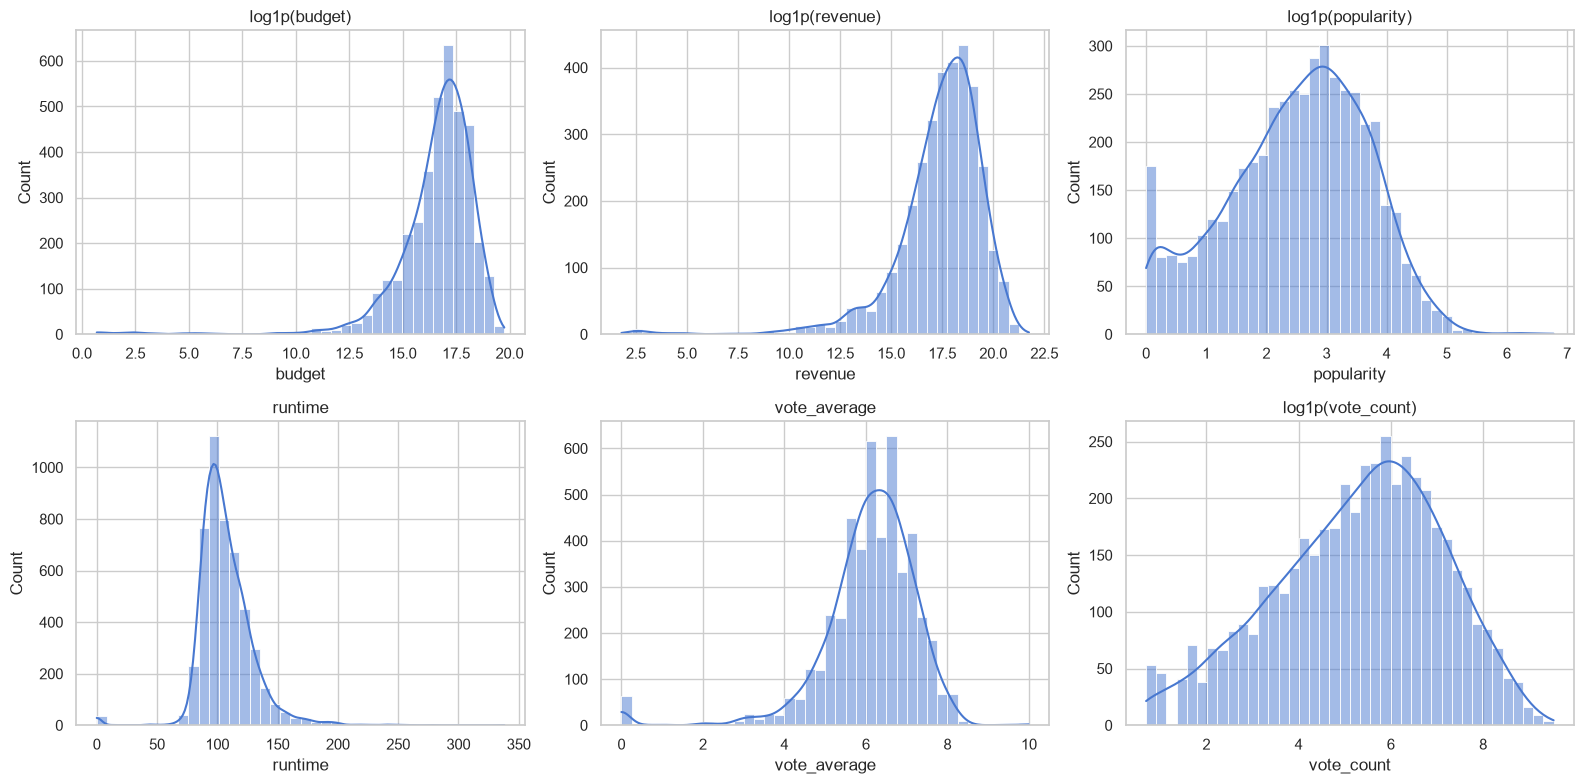

In [8]:
numeric_cols = ['budget', 'revenue', 'popularity', 'runtime', 'vote_average', 'vote_count']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, numeric_cols):
    data = movies_raw[col].dropna()
    # log-scale the heavily skewed money/count columns for a readable histogram
    if col in ('budget', 'revenue', 'popularity', 'vote_count'):
        data = np.log1p(data[data > 0])
        ax.set_title(f'log1p({col})')
    else:
        ax.set_title(col)
    sns.histplot(data, bins=40, kde=True, ax=ax)
plt.tight_layout()
plt.show()


In [9]:
movies_raw[numeric_cols].describe()

,budget,revenue,popularity,runtime,vote_average,vote_count
count,4.803000e+03,4.803000e+03,4803.000000,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,8.226064e+07,21.492301,106.875859,6.092172,690.217989
std,4.072239e+07,1.628571e+08,31.816650,22.611935,1.194612,1234.585891
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,7.900000e+05,0.000000e+00,4.668070,94.000000,5.600000,54.000000
50%,1.500000e+07,1.917000e+07,12.921594,103.000000,6.200000,235.000000
75%,4.000000e+07,9.291719e+07,28.313505,118.000000,6.800000,737.000000
max,3.800000e+08,2.787965e+09,875.581305,338.000000,10.000000,13752.000000


**Observations to expect:** `budget` and `revenue` are heavily right-skewed with a lot
of zeros (unreported values, not truly free movies) — these zeros should be treated as
missing, not real. `vote_count` is also extremely skewed, which matters for the popularity
baseline in Section 5 (a movie with 10 votes at 9.0 shouldn't outrank one with 5,000 votes
at 8.5).

### 3.3 Genre analysis

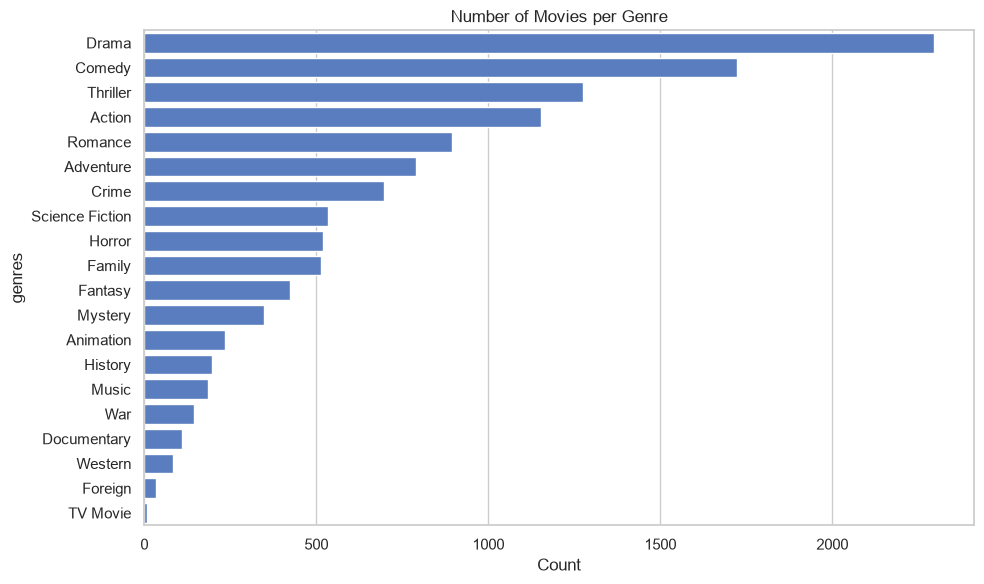

In [10]:
def parse_json_list(obj, key='name'):
    try:
        return [d[key] for d in ast.literal_eval(obj)]
    except (ValueError, SyntaxError, TypeError):
        return []

genre_series = movies_raw['genres'].apply(parse_json_list)
genre_counts = genre_series.explode().value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, orient='h')
plt.title('Number of Movies per Genre')
plt.xlabel('Count')
plt.tight_layout()
plt.show()


### 3.4 Release trends

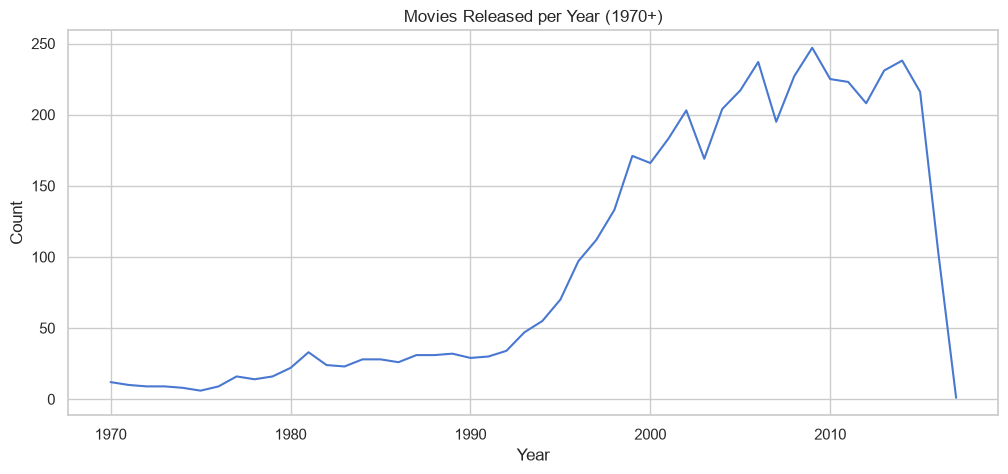

In [11]:
movies_raw['release_year_tmp'] = pd.to_datetime(movies_raw['release_date'], errors='coerce').dt.year

yearly_counts = movies_raw['release_year_tmp'].value_counts().sort_index()
yearly_counts = yearly_counts[yearly_counts.index >= 1970]

plt.figure(figsize=(12, 5))
yearly_counts.plot(kind='line')
plt.title('Movies Released per Year (1970+)')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()


### 3.5 Correlations between numeric features

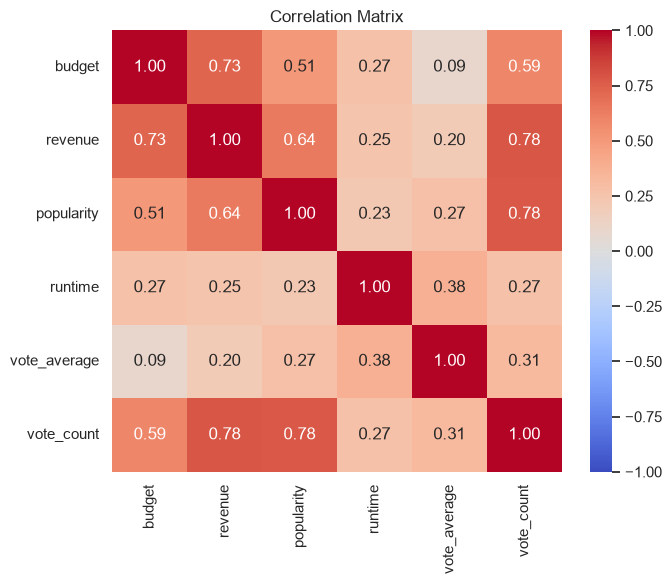

In [12]:
plt.figure(figsize=(7, 6))
corr = movies_raw[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


### 3.6 Overview text length

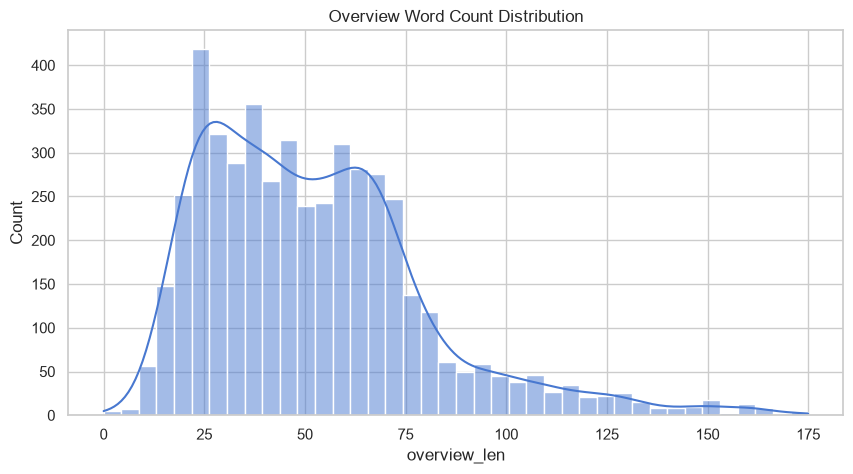

In [13]:
movies_raw['overview_len'] = movies_raw['overview'].fillna('').apply(lambda x: len(x.split()))

plt.figure()
sns.histplot(movies_raw['overview_len'], bins=40, kde=True)
plt.title('Overview Word Count Distribution')
plt.show()

movies_raw.drop(columns=['release_year_tmp', 'overview_len'], inplace=True)


## 4. Data Cleaning & Feature Engineering

### 4.1 Merge & select relevant columns

In [14]:
movies = movies_raw.merge(credits_raw, on='title')

# Keep everything we'll need for both EDA-driven numeric features and the text corpus
keep_cols = ['movie_id', 'title', 'overview', 'genres', 'keywords', 'cast', 'crew',
             'release_date', 'runtime', 'vote_average', 'vote_count', 'popularity']
movies = movies[keep_cols]
movies.head(2)


,movie_id,title,overview,genres,keywords,cast,crew,release_date,runtime,vote_average,vote_count,popularity
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",2009-12-10,162.0,7.2,11800,150.437577
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",2007-05-19,169.0,6.9,4500,139.082615


### 4.2 Handle missing / zero-as-missing values

In [15]:
movies.dropna(subset=['overview', 'genres', 'keywords', 'cast', 'crew'], inplace=True)
movies.drop_duplicates(subset=['title'], inplace=True)

# runtime / vote_average can have a handful of NaNs — impute with median rather than dropping rows
for col in ['runtime', 'vote_average', 'vote_count']:
    movies[col] = movies[col].fillna(movies[col].median())

movies.reset_index(drop=True, inplace=True)
print(movies.shape)
movies.isnull().sum()


(4797, 12)


movie_id        0
title           0
overview        0
genres          0
keywords        0
cast            0
crew            0
release_date    1
runtime         0
vote_average    0
vote_count      0
popularity      0
dtype: int64

### 4.3 Parse JSON-like columns

In [16]:
def convert(obj):
    return [d['name'] for d in ast.literal_eval(obj)]

def convert_top_n(obj, n=3):
    out = []
    for i, d in enumerate(ast.literal_eval(obj)):
        if i >= n:
            break
        out.append(d['name'])
    return out

def fetch_director(obj):
    for d in ast.literal_eval(obj):
        if d['job'] == 'Director':
            return [d['name']]
    return []

movies['genres'] = movies['genres'].apply(convert)
movies['keywords'] = movies['keywords'].apply(convert)
movies['cast'] = movies['cast'].apply(lambda x: convert_top_n(x, n=3))
movies['director'] = movies['crew'].apply(fetch_director)
movies.head(2)


,movie_id,title,overview,genres,keywords,cast,crew,release_date,runtime,vote_average,vote_count,popularity,director
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",2009-12-10,162.0,7.2,11800,150.437577,[James Cameron]
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley]","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",2007-05-19,169.0,6.9,4500,139.082615,[Gore Verbinski]


### 4.4 Derived numeric / categorical features

In [17]:
movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')
movies['release_year'] = movies['release_date'].dt.year
movies['release_decade'] = (movies['release_year'] // 10 * 10)
movies['num_genres'] = movies['genres'].apply(len)
movies['num_keywords'] = movies['keywords'].apply(len)

movies[['title', 'release_year', 'release_decade', 'num_genres', 'num_keywords']].head()


,title,release_year,release_decade,num_genres,num_keywords
0,Avatar,2009.0,2000.0,4,21
1,Pirates of the Caribbean: At World's End,2007.0,2000.0,3,16
2,Spectre,2015.0,2010.0,3,7
3,The Dark Knight Rises,2012.0,2010.0,4,21
4,John Carter,2012.0,2010.0,3,16


### 4.5 Weighted rating (IMDB formula)

`vote_average` alone is misleading — a movie with 3 votes at 10.0 shouldn't beat one with
8,000 votes at 8.2. The classic IMDB weighted rating fixes this and becomes the quality
signal for the popularity baseline and the hybrid re-ranker later on.

$$WR = \frac{v}{v+m}R + \frac{m}{v+m}C$$

where *v* = vote_count, *R* = vote_average, *m* = minimum votes threshold (90th percentile),
*C* = mean vote_average across the dataset.

In [18]:
C = movies['vote_average'].mean()
m = movies['vote_count'].quantile(0.90)

def weighted_rating(row, m=m, C=C):
    v, R = row['vote_count'], row['vote_average']
    return (v / (v + m) * R) + (m / (v + m) * C)

movies['weighted_rating'] = movies.apply(weighted_rating, axis=1)
movies[['title', 'vote_count', 'vote_average', 'weighted_rating']].sort_values(
    'weighted_rating', ascending=False).head(10)


,title,vote_count,vote_average,weighted_rating
1881,The Shawshank Redemption,8205,8.5,8.058204
662,Fight Club,9413,8.3,7.938380
65,The Dark Knight,12002,8.2,7.919316
3230,Pulp Fiction,8428,8.3,7.903704
96,Inception,13752,8.1,7.862636
3335,The Godfather,5893,8.4,7.850029
95,Interstellar,10867,8.1,7.808763
809,Forrest Gump,7927,8.2,7.802261
329,The Lord of the Rings: The Return of the King,8064,8.1,7.726375
1990,The Empire Strikes Back,5879,8.2,7.696793


### 4.6 Build the text corpus ('tags')

In [19]:
movies['overview_tokens'] = movies['overview'].apply(lambda x: x.split())

# strip internal spaces so multi-word entities become single tokens
# (e.g. "Science Fiction" -> "ScienceFiction", "Sam Worthington" -> "SamWorthington")
for col in ['genres', 'keywords', 'cast', 'director']:
    movies[col] = movies[col].apply(lambda lst: [str(i).replace(" ", "") for i in lst])

movies['tags'] = (movies['overview_tokens'] + movies['genres'] + movies['keywords']
                   + movies['cast'] + movies['director'])
movies['tags'] = movies['tags'].apply(lambda x: " ".join(x).lower())
movies[['title', 'tags']].head(3)


,title,tags
0,Avatar,"in the 22nd century, a paraplegic marine is di..."
1,Pirates of the Caribbean: At World's End,"captain barbossa, long believed to be dead, ha..."
2,Spectre,a cryptic message from bond’s past sends him o...


### 4.7 Text normalization (stemming)

In [20]:
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)

ps = PorterStemmer()

def stem(text):
    return " ".join(ps.stem(w) for w in text.split())

movies['tags'] = movies['tags'].apply(stem)
movies['tags'].iloc[0][:300]


'in the 22nd century, a parapleg marin is dispatch to the moon pandora on a uniqu mission, but becom torn between follow order and protect an alien civilization. action adventur fantasi sciencefict cultureclash futur spacewar spacecoloni societi spacetravel futurist romanc space alien tribe alienplan'

## 5. Baseline Model — Popularity-Based Recommender

Simplest possible baseline: same top-N list for everyone, ranked by weighted rating,
optionally filtered by genre. Every "smarter" model below has to beat this to justify its
complexity.

In [21]:
def popularity_recommend(genre=None, n=10):
    df = movies.copy()
    if genre is not None:
        df = df[df['genres'].apply(lambda g: genre.replace(" ", "") in g)]
    return df.sort_values('weighted_rating', ascending=False)[
        ['title', 'weighted_rating', 'vote_count', 'vote_average']].head(n)

popularity_recommend(genre='Action')


,title,weighted_rating,vote_count,vote_average
65,The Dark Knight,7.919316,12002,8.2
96,Inception,7.862636,13752,8.1
329,The Lord of the Rings: The Return of the King,7.726375,8064,8.1
1990,The Empire Strikes Back,7.696793,5879,8.2
262,The Lord of the Rings: The Fellowship of the Ring,7.666561,8705,8.0
2910,Star Wars,7.662842,6624,8.1
330,The Lord of the Rings: The Two Towers,7.623038,7487,8.0
94,Guardians of the Galaxy,7.612323,9742,7.9
634,The Matrix,7.589980,8907,7.9
571,Inglourious Basterds,7.497174,6430,7.9


## 6. Content-Based Filtering

We compare two vectorization strategies and a few hyperparameter settings, rather than
locking in `CountVectorizer(max_features=5000)` by default.

### 6.1 Vectorize with CountVectorizer (bag-of-words, original approach)

In [22]:
cv = CountVectorizer(max_features=5000, stop_words='english')
cv_vectors = cv.fit_transform(movies['tags'])
cv_similarity = cosine_similarity(cv_vectors)
print(cv_vectors.shape)


(4797, 5000)


### 6.2 Vectorize with TF-IDF

TF-IDF down-weights tokens that appear in almost every movie's tags (generic overview
words) and up-weights distinctive ones (rare keywords, specific cast/director names) —
usually a better signal for content similarity than raw counts.

In [23]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
tfidf_vectors = tfidf.fit_transform(movies['tags'])
tfidf_similarity = linear_kernel(tfidf_vectors, tfidf_vectors)  # equivalent to cosine sim for L2-normalized TF-IDF
print(tfidf_vectors.shape)


(4797, 5000)


### 6.3 Generic recommend function

In [24]:
title_to_index = pd.Series(movies.index, index=movies['title'])

def recommend(title, similarity_matrix, n=5):
    if title not in title_to_index:
        raise ValueError(f"'{title}' not found in dataset.")
    idx = title_to_index[title]
    scores = list(enumerate(similarity_matrix[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:n+1]
    return movies.iloc[[i for i, _ in scores]][['title', 'weighted_rating']].assign(
        similarity=[s for _, s in scores])

print("CountVectorizer recommendations for 'Avatar':")
display(recommend('Avatar', cv_similarity))

print("\nTF-IDF recommendations for 'Avatar':")
display(recommend('Avatar', tfidf_similarity))


CountVectorizer recommendations for 'Avatar':


,title,weighted_rating,similarity
1213,Aliens vs Predator: Requiem,5.751282,0.286770
2403,Aliens,7.114686,0.269014
3721,Falcon Rising,6.070854,0.260513
507,Independence Day,6.480608,0.255609
539,Titan A.E.,6.122886,0.250387



TF-IDF recommendations for 'Avatar':


,title,weighted_rating,similarity
3721,Falcon Rising,6.070854,0.209359
2403,Aliens,7.114686,0.208283
47,Star Trek Into Darkness,7.015012,0.208195
778,Meet Dave,5.909819,0.199202
582,Battle: Los Angeles,5.832102,0.190192


## 7. Model Selection & Evaluation

There's no ground-truth "user liked this" label in this dataset, so we use a standard proxy
for content-based recommenders: **genre-overlap precision@k** — for a sample of seed movies,
what fraction of the top-k recommendations share at least one genre with the seed? A good
content model should score meaningfully above a random baseline.

In [25]:
def genre_overlap_precision_at_k(similarity_matrix, k=10, sample_size=150, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    sample_idx = rng.choice(movies.index, size=min(sample_size, len(movies)), replace=False)

    hits, total = 0, 0
    for idx in sample_idx:
        seed_genres = set(movies.loc[idx, 'genres'])
        if not seed_genres:
            continue
        scores = list(enumerate(similarity_matrix[idx]))
        scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:k+1]
        for rec_idx, _ in scores:
            rec_genres = set(movies.loc[rec_idx, 'genres'])
            total += 1
            if seed_genres & rec_genres:
                hits += 1
    return hits / total if total else 0.0

def random_baseline_precision_at_k(k=10, sample_size=150, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    sample_idx = rng.choice(movies.index, size=min(sample_size, len(movies)), replace=False)
    n = len(movies)
    hits, total = 0, 0
    for idx in sample_idx:
        seed_genres = set(movies.loc[idx, 'genres'])
        if not seed_genres:
            continue
        rec_idx = rng.choice(n, size=k, replace=False)
        for r in rec_idx:
            rec_genres = set(movies.loc[r, 'genres'])
            total += 1
            if seed_genres & rec_genres:
                hits += 1
    return hits / total if total else 0.0


In [26]:
results = {
    'Random baseline': random_baseline_precision_at_k(k=10),
    'CountVectorizer (max_features=5000)': genre_overlap_precision_at_k(cv_similarity, k=10),
    'TF-IDF (1-2 grams, max_features=5000)': genre_overlap_precision_at_k(tfidf_similarity, k=10),
}

results_df = pd.DataFrame(results.items(), columns=['Model', 'Precision@10 (genre overlap)'])
results_df.sort_values('Precision@10 (genre overlap)', ascending=False)


,Model,Precision@10 (genre overlap)
1,CountVectorizer (max_features=5000),0.886667
2,"TF-IDF (1-2 grams, max_features=5000)",0.785333
0,Random baseline,0.508667


### 7.1 Hyperparameter sweep for TF-IDF

In [27]:
sweep_results = []
for max_features in [2000, 5000, 8000]:
    for ngram_range in [(1, 1), (1, 2)]:
        vec = TfidfVectorizer(max_features=max_features, stop_words='english', ngram_range=ngram_range)
        vecs = vec.fit_transform(movies['tags'])
        sim = linear_kernel(vecs, vecs)
        score = genre_overlap_precision_at_k(sim, k=10, sample_size=100)
        sweep_results.append({'max_features': max_features, 'ngram_range': str(ngram_range),
                               'precision@10': score})

sweep_df = pd.DataFrame(sweep_results).sort_values('precision@10', ascending=False)
sweep_df


,max_features,ngram_range,precision@10
1,2000,"(1, 2)",0.800
3,5000,"(1, 2)",0.793
5,8000,"(1, 2)",0.782
0,2000,"(1, 1)",0.772
2,5000,"(1, 1)",0.768
4,8000,"(1, 1)",0.765


**Selecting the best model:** pick the configuration with the highest precision@10 from
the sweep above (ties broken toward the smaller `max_features`, since it's cheaper to store
and serve). Re-fit it as `best_vectorizer` / `best_similarity` for the rest of the notebook.

In [28]:
best_row = sweep_df.iloc[0]
best_ngram = ast.literal_eval(best_row['ngram_range'])
best_max_features = int(best_row['max_features'])

best_vectorizer = TfidfVectorizer(max_features=best_max_features, stop_words='english', ngram_range=best_ngram)
best_vectors = best_vectorizer.fit_transform(movies['tags'])
best_similarity = linear_kernel(best_vectors, best_vectors)

print(f"Best config: max_features={best_max_features}, ngram_range={best_ngram}, "
      f"precision@10={best_row['precision@10']:.3f}")


Best config: max_features=2000, ngram_range=(1, 2), precision@10=0.800


## 8. Hybrid Recommender

Pure content similarity can surface obscure, poorly-rated movies just because their tags
overlap. The hybrid approach widens the candidate pool with content similarity, then
re-ranks by a blend of similarity and quality (`weighted_rating`), which is closer to what
production recommenders actually do.

In [29]:
def hybrid_recommend(title, n=5, pool_size=30, alpha=0.7):
    """alpha weights content similarity vs. weighted rating (0-1)."""
    idx = title_to_index[title]
    scores = list(enumerate(best_similarity[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:pool_size+1]

    candidates = movies.iloc[[i for i, _ in scores]].copy()
    candidates['sim_score'] = [s for _, s in scores]

    scaler = MinMaxScaler()
    candidates['sim_norm'] = scaler.fit_transform(candidates[['sim_score']])
    candidates['rating_norm'] = scaler.fit_transform(candidates[['weighted_rating']])

    candidates['final_score'] = alpha * candidates['sim_norm'] + (1 - alpha) * candidates['rating_norm']
    return candidates.sort_values('final_score', ascending=False)[
        ['title', 'sim_score', 'weighted_rating', 'final_score']].head(n)

hybrid_recommend('Avatar')


,title,sim_score,weighted_rating,final_score
3721,Falcon Rising,0.349357,6.070854,0.794673
2403,Aliens,0.240413,7.114686,0.536442
47,Star Trek Into Darkness,0.215811,7.015012,0.416332
1213,Aliens vs Predator: Requiem,0.263127,5.751282,0.379174
74,Edge of Tomorrow,0.189380,7.185249,0.338391


## 9. Persist Model Artifacts

Save the movie table and the winning similarity matrix so a downstream app (e.g. a
Streamlit/Flask front-end) doesn't need to recompute everything on every request.

In [30]:
import pickle

Path("artifacts").mkdir(exist_ok=True)

pickle.dump(movies.to_dict(), open("artifacts/movie_dict.pkl", "wb"))
pickle.dump(best_similarity, open("artifacts/similarity.pkl", "wb"))
pickle.dump(best_vectorizer, open("artifacts/vectorizer.pkl", "wb"))

print("Saved: artifacts/movie_dict.pkl, artifacts/similarity.pkl, artifacts/vectorizer.pkl")


Saved: artifacts/movie_dict.pkl, artifacts/similarity.pkl, artifacts/vectorizer.pkl


## 10. Conclusion & Next Steps

- EDA showed `vote_count` and `budget`/`revenue` are heavily skewed, motivating the IMDB
  weighted-rating quality signal used in the popularity and hybrid models.
- TF-IDF beat plain `CountVectorizer` on the genre-overlap precision@k proxy metric, and a
  small hyperparameter sweep picked the best `max_features` / `ngram_range` combination.
- The hybrid model blends content similarity with quality, which tends to reduce
  "technically similar but bad movie" recommendations compared to pure content-based
  filtering.

**Further improvements, if a user-ratings dataset becomes available (e.g. MovieLens):**
- Collaborative filtering (matrix factorization / SVD, or a neural CF model) to capture
  actual user taste rather than just item-to-item content similarity.
- A learned hybrid (e.g. LightFM) that blends content and collaborative signals natively.
- Replace TF-IDF with sentence embeddings (e.g. `sentence-transformers`) for semantic
  similarity on the `overview` text.
- Proper offline evaluation with held-out user interactions (precision/recall/NDCG@k)
  instead of the genre-overlap proxy used here.
